# Spatial RAG Evaluation Notebook

This notebook follows the updated evaluation plan:
- Retrieval: `Recall@k`, `nDCG@k`
- Generation: token-level `F1`, citation correctness
- Security: `ALE`
- Tradeoff: sweep over `(epsilon, lambda)` and report privacy-vs-utility


## 0) Environment

Run with your project venv:

```bash
cd /Users/shayan/Projects/PAS_RAG
source .venv_pas_rag/bin/activate
```


In [1]:
from pathlib import Path
from collections import Counter
import csv
import json
import math
import re
import statistics
import time

from utils import generate_grounded_answer
import pas_rag_end_to_end_patched as pas

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

BASE = Path.cwd()
OUTPUT_DIR = BASE / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Working directory:', BASE)
print('Output dir:', OUTPUT_DIR)


Working directory: /Users/shayan/Projects/PAS_RAG
Output dir: /Users/shayan/Projects/PAS_RAG/outputs


/Users/shayan/Projects/PAS_RAG/.venv_pas_rag/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Load Data


In [2]:
anchors = pas.load_jsonl(BASE / 'expanded_anchor_registry.jsonl')
chunks = pas.load_jsonl(BASE / 'expanded_chunks.jsonl')
queries = pas.load_jsonl(BASE / 'expanded_eval_queries.jsonl')

print('anchors:', len(anchors))
print('chunks:', len(chunks))
print('queries:', len(queries))


anchors: 30
chunks: 1010
queries: 423


## 2) Config

- `top_k`: retrieval cutoff
- `max_queries`: set an int (e.g., 50) for quick smoke runs
- `epsilon`: PAS privacy parameter
- `lambda_weight`: semantic/spatial fusion weight in retrieval score


In [3]:
CONFIG = {
    'top_k': 5,
    'max_queries': None,
    'mc_samples': 250,
    'epsilon': 1.0,
    'scale_m': 500.0,
    'lambda_weight': 0.65,
    'progress_every': 25,
}

EPSILON_GRID = [0.2, 0.5, 1.0, 2.0]
LAMBDA_GRID = [0.5, 0.65, 0.8]

SWEEP_CONFIG = dict(CONFIG)
SWEEP_CONFIG['mc_samples'] = 100   # faster sweep; keep full CONFIG for final single-point eval
SWEEP_CONFIG['max_queries'] = 100      # faster sweep with visible progress

print(CONFIG)
print('SWEEP_CONFIG:', SWEEP_CONFIG)
print('epsilon grid:', EPSILON_GRID)
print('lambda grid:', LAMBDA_GRID)


{'top_k': 5, 'max_queries': None, 'mc_samples': 250, 'epsilon': 1.0, 'scale_m': 500.0, 'lambda_weight': 0.65, 'progress_every': 25}
SWEEP_CONFIG: {'top_k': 5, 'max_queries': 100, 'mc_samples': 100, 'epsilon': 1.0, 'scale_m': 500.0, 'lambda_weight': 0.65, 'progress_every': 25}
epsilon grid: [0.2, 0.5, 1.0, 2.0]
lambda grid: [0.5, 0.65, 0.8]


## 3) Metric Helpers

Assumption for `ALE`: in this notebook, `ALE` is modeled as **attacker localization error** in meters,
using a simple token-centroid attacker estimate derived from released PAS `(anchor, direction_bin, distance_bin)`.


In [4]:
def normalize_token(t):
    return re.sub(r'[^a-z0-9]+', '', t.lower())


def tokenize_text(s):
    return [normalize_token(x) for x in re.findall(r"[A-Za-z0-9']+", s.lower()) if normalize_token(x)]


def token_f1(pred, ref):
    p = tokenize_text(pred)
    r = tokenize_text(ref)
    if not p or not r:
        return 0.0
    pc = Counter(p)
    rc = Counter(r)
    overlap = sum((pc & rc).values())
    if overlap == 0:
        return 0.0
    precision = overlap / len(p)
    recall = overlap / len(r)
    return 2 * precision * recall / (precision + recall)


def dcg_at_k(relevances, k):
    rel = relevances[:k]
    return sum((r / math.log2(i + 2)) for i, r in enumerate(rel))


def ndcg_at_k(retrieved_doc_ids, ground_truth_doc_ids, k):
    gt = set(ground_truth_doc_ids)
    rel = [1 if d in gt else 0 for d in retrieved_doc_ids[:k]]
    dcg = dcg_at_k(rel, k)
    ideal_rel = [1] * min(len(gt), k)
    idcg = dcg_at_k(ideal_rel, k)
    return (dcg / idcg) if idcg > 0 else 0.0


def citation_correctness(citations, ground_truth_doc_ids):
    gt = set(ground_truth_doc_ids)
    if not citations:
        return 0.0
    cited = [c.get('doc_id') for c in citations if c.get('doc_id')]
    if not cited:
        return 0.0
    correct = sum(1 for d in cited if d in gt)
    return correct / len(cited)


def ring_bounds_m(distance_bin):
    if distance_bin == '0-0.5mi':
        return 0.0, 0.5 * 1609.344
    if distance_bin == '0.5-1mi':
        return 0.5 * 1609.344, 1.0 * 1609.344
    if distance_bin == '1-2mi':
        return 1.0 * 1609.344, 2.0 * 1609.344
    return 0.0, 2.0 * 1609.344


def ale_from_token(query, token, anchor_lookup):
    # Attacker estimate: sector midpoint of released PAS token.
    anchor = anchor_lookup[token['anchor_id']]
    anchor_loc = (anchor['geo']['lat'], anchor['geo']['lon'])
    rmin, rmax = ring_bounds_m(token['distance_bin'])
    r_mid = (rmin + rmax) / 2.0
    center_map = {'N': 0, 'NE': 45, 'E': 90, 'SE': 135, 'S': 180, 'SW': 225, 'W': 270, 'NW': 315, 'ANY': 0}
    b = center_map[token['direction_bin']]
    est = pas.offset_from_anchor(anchor_loc[0], anchor_loc[1], r_mid, b)

    true_loc = (
        query['spatial_intent']['user_location']['lat'],
        query['spatial_intent']['user_location']['lon'],
    )
    return pas.haversine_m(true_loc, est)


def build_reference_answer_from_ground_truth(query, gt_chunks):
    if not gt_chunks:
        return ''
    titles = ', '.join(c['title'] for c in gt_chunks[:3])
    facts = []
    for c in gt_chunks[:3]:
        facts.extend(c.get('supporting_facts', [])[:1])
    return f"For query '{query['raw_query']}', relevant places include {titles}. " + ' '.join(facts)


## 4) Retrieval Helpers


In [5]:
chunk_by_doc = {}
for c in chunks:
    # Keep first chunk per doc_id in this dataset layout.
    chunk_by_doc.setdefault(c['doc_id'], c)


def exact_location_retrieve(query, chunks, top_k=3, lambda_weight=0.65):
    user_loc = (
        query['spatial_intent']['user_location']['lat'],
        query['spatial_intent']['user_location']['lon'],
    )
    radius_m = query['spatial_intent']['radius_miles'] * 1609.344
    required_dir = query['spatial_intent']['direction_constraint']

    ranked = []
    for chunk in chunks:
        sem = pas.semantic_score(query, chunk)
        geo = chunk.get('metadata', {}).get('geo', {}) or {}
        lat, lon = geo.get('lat'), geo.get('lon')
        spa = 0.0

        if lat is not None and lon is not None:
            item_loc = (lat, lon)
            d = pas.haversine_m(user_loc, item_loc)
            within = d <= radius_m
            directional = True if required_dir == 'ANY' else (pas.dir_bin(pas.bearing_deg(user_loc, item_loc)) == required_dir)
            if within and directional:
                spa = 1.0
            elif within:
                spa = 0.45

        score = lambda_weight * sem + (1 - lambda_weight) * spa
        ranked.append({
            'doc_id': chunk['doc_id'],
            'chunk_id': chunk['chunk_id'],
            'title': chunk['title'],
            'category': chunk['category'],
            'score': round(score, 4),
            'semantic_score': round(sem, 4),
            'spatial_score': round(spa, 4),
            'metadata': chunk['metadata'],
            'content': chunk['content'],
            'supporting_facts': chunk.get('supporting_facts', []),
        })

    ranked.sort(key=lambda x: (x['score'], x['semantic_score'], x['spatial_score'], x['title']), reverse=True)
    return ranked[:top_k]


## 5) Baseline Evaluation Cell (Exact Location)

This cell evaluates **baseline only** (no PAS obfuscation).


In [6]:
def evaluate_baseline(queries, chunks, cfg):
    selected = queries[:cfg['max_queries']] if cfg['max_queries'] else queries

    recalls, ndcgs, f1s, cites = [], [], [], []
    rows = []

    iterator = tqdm(selected, total=len(selected), desc='Baseline eval', unit='query')
    for i, q in enumerate(iterator, start=1):
        top = exact_location_retrieve(q, chunks, top_k=cfg['top_k'], lambda_weight=cfg['lambda_weight'])
        top_doc_ids = [r['doc_id'] for r in top]

        rec = pas.recall_at_k(q['ground_truth_doc_ids'], top, k=cfg['top_k'])
        nd = ndcg_at_k(top_doc_ids, q['ground_truth_doc_ids'], cfg['top_k'])

        gen = generate_grounded_answer(q, top)
        pred_answer = gen['answer']
        gt_chunks = [chunk_by_doc[d] for d in q['ground_truth_doc_ids'] if d in chunk_by_doc]
        ref_answer = build_reference_answer_from_ground_truth(q, gt_chunks)

        f1 = token_f1(pred_answer, ref_answer)
        cc = citation_correctness(gen.get('citations', []), q['ground_truth_doc_ids'])

        recalls.append(rec)
        ndcgs.append(nd)
        f1s.append(f1)
        cites.append(cc)

        rows.append({
            'qid': q['qid'],
            'query': q['raw_query'],
            'mode': 'baseline',
            'epsilon': None,
            'lambda_weight': cfg['lambda_weight'],
            'recall_at_k': round(rec, 4),
            'ndcg_at_k': round(nd, 4),
            'gen_f1': round(f1, 4),
            'citation_correctness': round(cc, 4),
            'ale_m': 0.0,
            'top_doc_ids': ';'.join(top_doc_ids),
        })

        if i % cfg['progress_every'] == 0 and hasattr(iterator, 'set_postfix'):
            iterator.set_postfix(recall=round(statistics.mean(recalls), 3), ndcg=round(statistics.mean(ndcgs), 3))

    summary = {
        'mode': 'baseline',
        'n_queries': len(selected),
        'lambda_weight': cfg['lambda_weight'],
        'mean_recall_at_k': round(statistics.mean(recalls), 4),
        'mean_ndcg_at_k': round(statistics.mean(ndcgs), 4),
        'mean_gen_f1': round(statistics.mean(f1s), 4),
        'mean_citation_correctness': round(statistics.mean(cites), 4),
        'mean_ale_m': 0.0,
    }
    return summary, rows

baseline_summary, baseline_rows = evaluate_baseline(queries, chunks, CONFIG)
print(json.dumps(baseline_summary, indent=2))


Baseline eval: 100%|██████████| 423/423 [19:43<00:00,  2.80s/query, ndcg=0.856, recall=0.9]  

{
  "mode": "baseline",
  "n_queries": 423,
  "lambda_weight": 0.65,
  "mean_recall_at_k": 0.903,
  "mean_ndcg_at_k": 0.8577,
  "mean_gen_f1": 0.34,
  "mean_citation_correctness": 0.6572,
  "mean_ale_m": 0.0
}


## 6) Defense Evaluation Cell (PAS)

This cell evaluates **PAS defense only** for a fixed `(epsilon, lambda)`.


In [ ]:
def evaluate_pas_defense(queries, chunks, anchors, cfg, show_progress=True):
    anchor_lookup = {a['anchor_id']: a for a in anchors}
    selected = queries[:cfg['max_queries']] if cfg['max_queries'] else queries

    recalls, ndcgs, f1s, cites, ales = [], [], [], [], []
    rows = []

    iterator = tqdm(selected, total=len(selected), desc='PAS defense eval', unit='query') if show_progress else selected
    for i, q in enumerate(iterator, start=1):
        parsed = pas.parse_query(q['raw_query'], fallback_query=q)
        token = pas.build_pas_token(parsed, anchors, epsilon=cfg['epsilon'], scale_m=cfg['scale_m'])
        latent = pas.build_latent_user_samples(parsed, token, mc_samples=cfg['mc_samples'])
        top = pas.hybrid_retrieve(
            parsed,
            chunks,
            pas_token=token,
            latent_user_samples=latent,
            top_k=cfg['top_k'],
            lambda_weight=cfg['lambda_weight'],
        )
        top_doc_ids = [r['doc_id'] for r in top]

        rec = pas.recall_at_k(q['ground_truth_doc_ids'], top, k=cfg['top_k'])
        nd = ndcg_at_k(top_doc_ids, q['ground_truth_doc_ids'], cfg['top_k'])

        gen = generate_grounded_answer(q, top)
        pred_answer = gen['answer']
        gt_chunks = [chunk_by_doc[d] for d in q['ground_truth_doc_ids'] if d in chunk_by_doc]
        ref_answer = build_reference_answer_from_ground_truth(q, gt_chunks)

        f1 = token_f1(pred_answer, ref_answer)
        cc = citation_correctness(gen.get('citations', []), q['ground_truth_doc_ids'])
        ale = ale_from_token(q, token, anchor_lookup)

        recalls.append(rec)
        ndcgs.append(nd)
        f1s.append(f1)
        cites.append(cc)
        ales.append(ale)

        rows.append({
            'qid': q['qid'],
            'query': q['raw_query'],
            'mode': 'pas_defense',
            'epsilon': cfg['epsilon'],
            'lambda_weight': cfg['lambda_weight'],
            'recall_at_k': round(rec, 4),
            'ndcg_at_k': round(nd, 4),
            'gen_f1': round(f1, 4),
            'citation_correctness': round(cc, 4),
            'ale_m': round(ale, 2),
            'pas_anchor_id': token['anchor_id'],
            'pas_direction_bin': token['direction_bin'],
            'pas_distance_bin': token['distance_bin'],
            'top_doc_ids': ';'.join(top_doc_ids),
        })

        if show_progress and i % cfg['progress_every'] == 0 and hasattr(iterator, 'set_postfix'):
            iterator.set_postfix(recall=round(statistics.mean(recalls), 3), ndcg=round(statistics.mean(ndcgs), 3), ale=round(statistics.mean(ales), 1))

    summary = {
        'mode': 'pas_defense',
        'n_queries': len(selected),
        'epsilon': cfg['epsilon'],
        'lambda_weight': cfg['lambda_weight'],
        'mean_recall_at_k': round(statistics.mean(recalls), 4),
        'mean_ndcg_at_k': round(statistics.mean(ndcgs), 4),
        'mean_gen_f1': round(statistics.mean(f1s), 4),
        'mean_citation_correctness': round(statistics.mean(cites), 4),
        'mean_ale_m': round(statistics.mean(ales), 2),
    }
    return summary, rows

pas_summary, pas_rows = evaluate_pas_defense(queries, chunks, anchors, CONFIG)
print(json.dumps(pas_summary, indent=2))


PAS defense eval: 100%|██████████| 423/423 [09:38<00:00,  1.37s/query, ale=387, ndcg=0.199, recall=0.256]

{
  "mode": "pas_defense",
  "n_queries": 423,
  "epsilon": 1.0,
  "lambda_weight": 0.65,
  "mean_recall_at_k": 0.2645,
  "mean_ndcg_at_k": 0.2035,
  "mean_gen_f1": 0.165,
  "mean_citation_correctness": 0.0913,
  "mean_ale_m": 386.02
}


## 7) Combined Utility-Privacy Tradeoff Sweep `(epsilon, lambda)`

This is the cell for plotting/analysis: x-axis `ALE`, y-axis retrieval quality (`Recall@k` or `nDCG@k`).


In [14]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import os


def _run_one_tradeoff_pair(eps, lam, queries, chunks, anchors, cfg):
    local_cfg = dict(cfg)
    local_cfg['epsilon'] = eps
    local_cfg['lambda_weight'] = lam
    summary, _ = evaluate_pas_defense(queries, chunks, anchors, local_cfg, show_progress=False)
    return {
        'epsilon': eps,
        'lambda_weight': lam,
        'mean_ale_m': summary['mean_ale_m'],
        'mean_recall_at_k': summary['mean_recall_at_k'],
        'mean_ndcg_at_k': summary['mean_ndcg_at_k'],
        'mean_gen_f1': summary['mean_gen_f1'],
        'mean_citation_correctness': summary['mean_citation_correctness'],
    }


def run_tradeoff_sweep(queries, chunks, anchors, epsilon_grid, lambda_grid, cfg, parallel=False, max_workers=None):
    pairs = [(e, l) for e in epsilon_grid for l in lambda_grid]

    if not parallel:
        out = []
        iterator = tqdm(pairs, total=len(pairs), desc='Sweep (epsilon,lambda)', unit='pair')
        for eps, lam in iterator:
            row = _run_one_tradeoff_pair(eps, lam, queries, chunks, anchors, cfg)
            out.append(row)
            if hasattr(iterator, 'set_postfix'):
                iterator.set_postfix(ale=row['mean_ale_m'], r=row['mean_recall_at_k'], ndcg=row['mean_ndcg_at_k'])
        return sorted(out, key=lambda x: (x['epsilon'], x['lambda_weight']))

    if max_workers is None:
        max_workers = min(len(pairs), max(1, (os.cpu_count() or 4) - 1), 8)

    out = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [
            ex.submit(_run_one_tradeoff_pair, eps, lam, queries, chunks, anchors, cfg)
            for eps, lam in pairs
        ]
        for fut in tqdm(as_completed(futures), total=len(futures), desc=f'Sweep parallel ({max_workers}w)', unit='pair'):
            out.append(fut.result())

    return sorted(out, key=lambda x: (x['epsilon'], x['lambda_weight']))


# Use lighter config for sweep to reduce runtime
tradeoff_rows = run_tradeoff_sweep(
    queries,
    chunks,
    anchors,
    EPSILON_GRID,
    LAMBDA_GRID,
    SWEEP_CONFIG,
    parallel=False,
)

for r in tradeoff_rows:
    print(r)


Sweep (epsilon,lambda): 100%|██████████| 12/12 [11:13<00:00, 56.14s/pair, ale=390, ndcg=0.148, r=0.2]     

{'epsilon': 0.2, 'lambda_weight': 0.5, 'mean_ale_m': 1244.44, 'mean_recall_at_k': 0.1217, 'mean_ndcg_at_k': 0.1118, 'mean_gen_f1': 0.1591, 'mean_citation_correctness': 0.066}
{'epsilon': 0.2, 'lambda_weight': 0.65, 'mean_ale_m': 1773.29, 'mean_recall_at_k': 0.1425, 'mean_ndcg_at_k': 0.1162, 'mean_gen_f1': 0.1628, 'mean_citation_correctness': 0.076}
{'epsilon': 0.2, 'lambda_weight': 0.8, 'mean_ale_m': 2040.82, 'mean_recall_at_k': 0.1658, 'mean_ndcg_at_k': 0.1427, 'mean_gen_f1': 0.1678, 'mean_citation_correctness': 0.072}
{'epsilon': 0.5, 'lambda_weight': 0.5, 'mean_ale_m': 554.19, 'mean_recall_at_k': 0.175, 'mean_ndcg_at_k': 0.1567, 'mean_gen_f1': 0.167, 'mean_citation_correctness': 0.088}
{'epsilon': 0.5, 'lambda_weight': 0.65, 'mean_ale_m': 511.09, 'mean_recall_at_k': 0.1833, 'mean_ndcg_at_k': 0.1393, 'mean_gen_f1': 0.1662, 'mean_citation_correctness': 0.088}
{'epsilon': 0.5, 'lambda_weight': 0.8, 'mean_ale_m': 507.01, 'mean_recall_at_k': 0.2008, 'mean_ndcg_at_k': 0.1628, 'mean_gen_f1

## 8) Save Outputs


In [ ]:
baseline_json = OUTPUT_DIR / 'baseline_eval_summary.json'
baseline_csv = OUTPUT_DIR / 'baseline_eval_per_query.csv'
pas_json = OUTPUT_DIR / 'pas_eval_summary.json'
pas_csv = OUTPUT_DIR / 'pas_eval_per_query.csv'
tradeoff_csv = OUTPUT_DIR / 'pas_tradeoff_epsilon_lambda.csv'

with baseline_json.open('w', encoding='utf-8') as f:
    json.dump({'summary': baseline_summary, 'rows': baseline_rows}, f, indent=2)
with pas_json.open('w', encoding='utf-8') as f:
    json.dump({'summary': pas_summary, 'rows': pas_rows}, f, indent=2)

for path, rows in [(baseline_csv, baseline_rows), (pas_csv, pas_rows), (tradeoff_csv, tradeoff_rows)]:
    if rows:
        with path.open('w', encoding='utf-8', newline='') as f:
            w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            w.writeheader()
            w.writerows(rows)

print('Saved:', baseline_json)
print('Saved:', baseline_csv)
print('Saved:', pas_json)
print('Saved:', pas_csv)
print('Saved:', tradeoff_csv)


## 9) Reader Notes

- **Baseline and defense are intentionally separated** into different execution cells.
- `nDCG@k` here uses binary relevance from provided ground-truth doc IDs.
- Generation `F1` is computed against a deterministic reference answer synthesized from ground-truth documents.
- Citation correctness uses cited `doc_id`s returned by the generation helper.
- `ALE` is implemented as attacker localization error (meters) from PAS token centroid inference.


## 10) Plot Sweep Results

This section loads the saved sweep output and visualizes privacy-utility tradeoffs.


Loaded 12 sweep points from /Users/shayan/Projects/PAS_RAG/outputs/pas_tradeoff_epsilon_lambda.csv


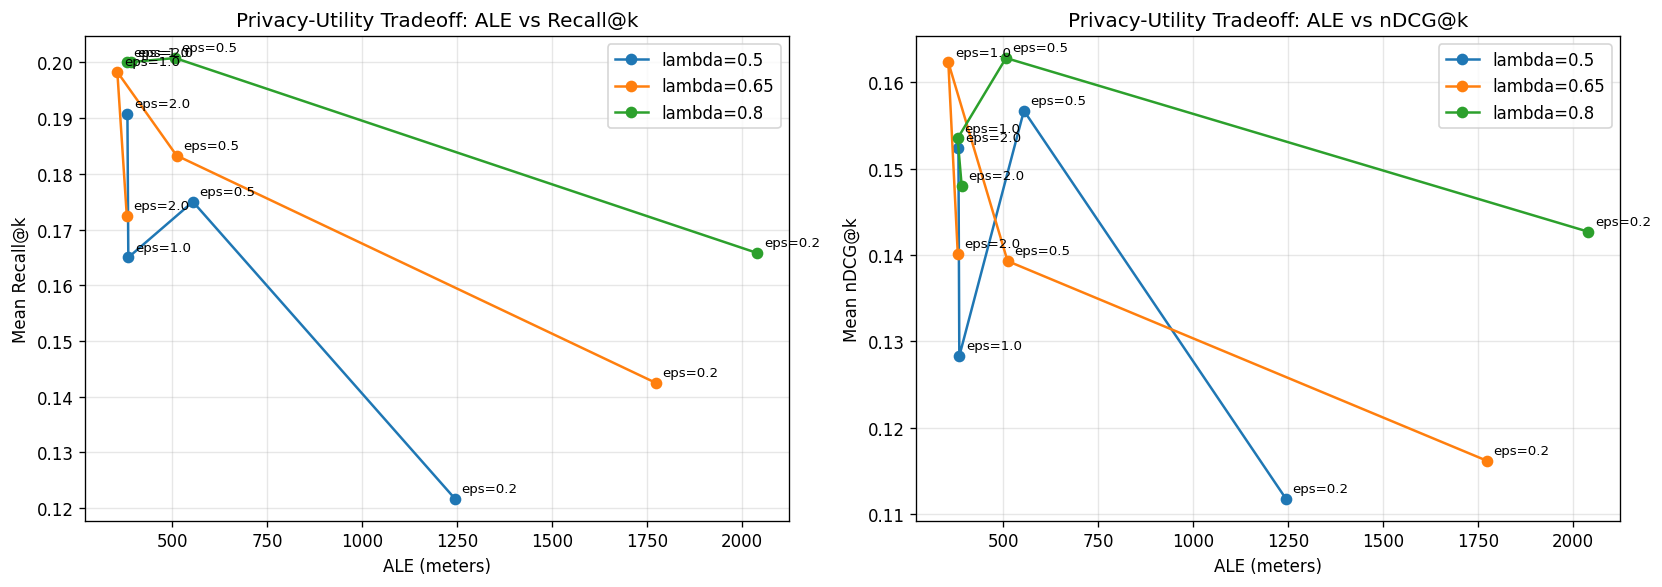

In [5]:
# Load sweep CSV and plot utility-privacy tradeoffs
import csv
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except Exception as e:
    raise RuntimeError("matplotlib is required for plotting. Install with: pip install matplotlib") from e

sweep_path = OUTPUT_DIR / 'pas_tradeoff_epsilon_lambda.csv'
if not sweep_path.exists():
    raise FileNotFoundError(f"Sweep file not found: {sweep_path}. Run the sweep cell first.")

rows = []
with sweep_path.open('r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append({
            'epsilon': float(r['epsilon']),
            'lambda_weight': float(r['lambda_weight']),
            'mean_ale_m': float(r['mean_ale_m']),
            'mean_recall_at_k': float(r['mean_recall_at_k']),
            'mean_ndcg_at_k': float(r['mean_ndcg_at_k']),
            'mean_gen_f1': float(r['mean_gen_f1']),
            'mean_citation_correctness': float(r['mean_citation_correctness']),
        })

if not rows:
    raise ValueError('Sweep CSV is empty.')

print(f'Loaded {len(rows)} sweep points from {sweep_path}')

# Sort for cleaner viewing
rows = sorted(rows, key=lambda x: (x['lambda_weight'], x['epsilon']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

for lam in sorted({r['lambda_weight'] for r in rows}):
    subset = [r for r in rows if r['lambda_weight'] == lam]
    x = [r['mean_ale_m'] for r in subset]
    y1 = [r['mean_recall_at_k'] for r in subset]
    y2 = [r['mean_ndcg_at_k'] for r in subset]
    labels = [f"eps={r['epsilon']}" for r in subset]

    axes[0].plot(x, y1, marker='o', label=f'lambda={lam}')
    axes[1].plot(x, y2, marker='o', label=f'lambda={lam}')

    for xi, yi, lab in zip(x, y1, labels):
        axes[0].annotate(lab, (xi, yi), textcoords='offset points', xytext=(4, 4), fontsize=8)
    for xi, yi, lab in zip(x, y2, labels):
        axes[1].annotate(lab, (xi, yi), textcoords='offset points', xytext=(4, 4), fontsize=8)

axes[0].set_title('Privacy-Utility Tradeoff: ALE vs Recall@k')
axes[0].set_xlabel('ALE (meters)')
axes[0].set_ylabel('Mean Recall@k')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title('Privacy-Utility Tradeoff: ALE vs nDCG@k')
axes[1].set_xlabel('ALE (meters)')
axes[1].set_ylabel('Mean nDCG@k')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
